# Projet IA : Reconnaissance de chiffres et de lettres manuscrits

## Réalisé par :
- Nom 1
- Nom 2
- Nom 3
- Nom 4

### Objectif

Développer une intelligence artificielle capable de reconnaître automatiquement :

- les chiffres manuscrits de 0 à 9 ;
- les lettres manuscrites de A à Z.

Le projet utilise un réseau de neurones convolutif (CNN).

### Bases de données utilisées

- MNIST : chiffres manuscrits
- EMNIST Letters : lettres manuscritesA

In [4]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Images entraînement :", x_train.shape)
print("Labels entraînement :", y_train.shape)

print("Images test :", x_test.shape)
print("Labels test :", y_test.shape)

Images entraînement : (60000, 28, 28)
Labels entraînement : (60000,)
Images test : (10000, 28, 28)
Labels test : (10000,)


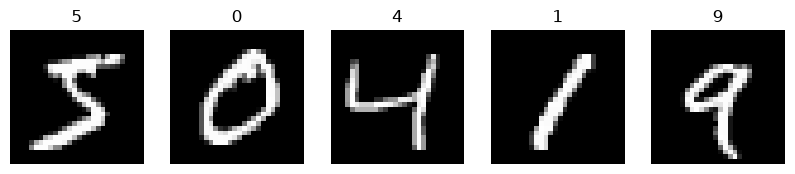

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(x_train[i], cmap="gray")

    plt.title(y_train[i])

    plt.axis("off")

plt.show()

# Architecture du CNN

Le réseau est composé de :

1. Une couche Convolutionnelle Conv2D avec 32 filtres.
2. Une couche MaxPooling.
3. Une deuxième couche Conv2D avec 64 filtres.
4. Une deuxième couche MaxPooling.
5. Une couche Flatten.
6. Une couche Dense avec 64 neurones.
7. Une couche Dense avec 10 neurones correspondant aux chiffres de 0 à 9.

In [6]:
model = tf.keras.models.load_model("mnist_model.keras")

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,792 (1.40 MB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,862 (952.59 KB)

In [7]:
img = x_test[0] / 255.0

img = img.reshape(1,28,28,1)

prediction = model.predict(img)

print("Prédiction :", prediction.argmax())

print("Vraie réponse :", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prédiction : 7
Vraie réponse : 7


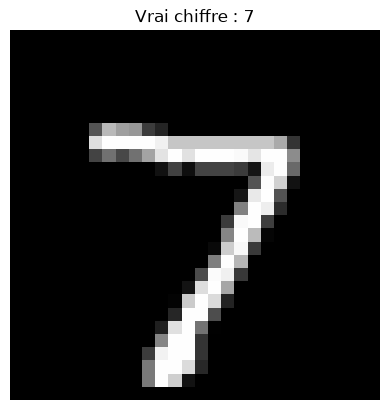

In [8]:
plt.imshow(x_test[0], cmap="gray")

plt.title(f"Vrai chiffre : {y_test[0]}")

plt.axis("off")

plt.show()

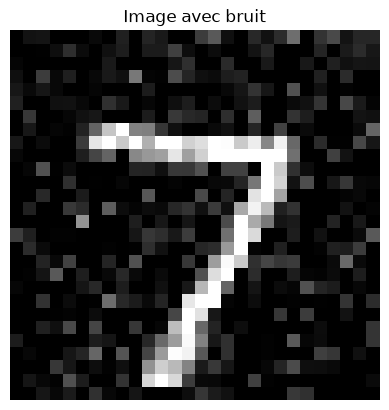

In [9]:
import numpy as np

img = x_test[0]

noise = np.random.normal(
    0,
    40,
    img.shape
)

img_noise = img + noise

img_noise = np.clip(
    img_noise,
    0,
    255
)

plt.imshow(
    img_noise,
    cmap="gray"
)

plt.title("Image avec bruit")

plt.axis("off")

plt.show()

In [10]:
import tensorflow_datasets as tfds

(ds_train, ds_test), ds_info = tfds.load(
    "emnist/letters",
    split=["train","test"],
    as_supervised=True,
    with_info=True
)

print(ds_info)

tfds.core.DatasetInfo(
    name='emnist',
    full_name='emnist/letters/3.1.0',
    description="""
    The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.
    
    Note: Like the original EMNIST data, images provided here are inverted horizontally and rotated 90 anti-clockwise. You can use `tf.transpose` within `ds.map` to convert the images to a human-friendlier format.
    """,
    config_description="""
    EMNIST Letters
    """,
    homepage='https://www.nist.gov/itl/products-and-services/emnist-dataset',
    data_dir='/Users/mimidben/tensorflow_datasets/emnist/letters/3.1.0',
    file_format=tfrecord,
    download_size=535.73 MiB,
    dataset_size=44.14 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=37),
    }),
    super

W0000 00:00:1781466687.084054 118552331 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


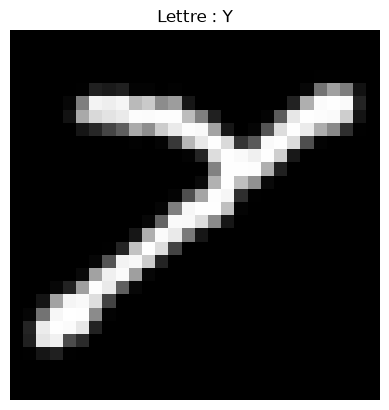

In [12]:
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

for image, label in ds_train.take(1):

    idx = int(label.numpy()) - 1

    plt.imshow(
        image.numpy().squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Lettre : {letters[idx]}"
    )

    plt.axis("off")

plt.show()

# Architecture du CNN

## Modèle pour les chiffres (MNIST)

Le réseau est composé de :

- Couche Conv2D avec 32 filtres (3×3)
- Couche MaxPooling (2×2)
- Couche Conv2D avec 64 filtres (3×3)
- Couche MaxPooling (2×2)
- Couche Flatten
- Couche Dense avec 64 neurones
- Couche Dense avec 10 neurones (classes 0 à 9)

---

## Modèle pour les lettres (EMNIST)

Le réseau est composé de :

- Conv2D(32)
- BatchNormalization
- MaxPooling
- Conv2D(64)
- BatchNormalization
- MaxPooling
- Conv2D(128)
- BatchNormalization
- Flatten
- Dense(128)
- Dropout(0.3)
- Dense(26) avec Softmax

In [13]:
model_digits = tf.keras.models.load_model("mnist_model.keras")

model_digits.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,792 (1.40 MB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,862 (952.59 KB)

In [14]:
model_letters = tf.keras.models.load_model("letters_model.keras")

model_letters.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 732,624 (2.79 MB)

 Trainable params: 244,058 (953.35 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 488,118 (1.86 MB)